# Setup

In [1]:
from pprint import pprint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Seed
seed = 42

# sklearn config
from sklearn import set_config
set_config(transform_output='pandas', display='text')

# Data

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X, y = load_iris(return_X_y=True, as_frame=True)

# Train / validation / test = 60% / 20% / 20%.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=seed,
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=seed,
)

# 1. Single Tree

## 1) Summary

### Algorithm

Given the data $X \in \mathbb{R}^{m \times n}$,

1. Calculate the impurity $I$ for each feature's split.
2. Choose the split with minimal impurity: $\displaystyle \min_{split}\ (\frac{N_{left}}{N}I_{left} + \frac{N_{right}}{N}I_{right})$
3. Grow the tree and repeat until the tree meets the stopping condition (pre-pruning).
4. Remove redundant leaves (post-pruning).

### Impurity

- $p_k = N_k/N$: proportion of class $k$ in the current node.
- $\text{Gini, } g = 1 - \displaystyle\sum_k p_k^2$.
- $\text{Entropy, } e = -\displaystyle\sum_k p_k \log_2 p_k$, with $0\log 0=0$.
- $\text{Impurity decrease, } \Delta I = I_{parent} - \displaystyle\sum_{child} \frac{N_{child}}{N}I_{child}$.
- With entropy, this decrease is called **information gain**.
- Regression with squared error: $I=\frac{1}{N}\sum_i(y_i-\bar y)^2$; each leaf predicts its mean $\bar y$.

### Cost-Complexity Pruning

- Post-pruning in `sklearn`.
- $R(T_t) = \text{sum of weighted impurity of all leaves}$
- $R(t) = \text{weighted impurity when all t's descendants are removed}$
- $|T_t| = \text{number of leaves in } T_t$
- $\alpha_{eff}(t) = \frac{R(t) - R(T_t)}{|T_t| - 1}$
- A node $t$ where $\alpha_{eff}(t)$ is the smallest, and $\alpha_{eff}(t) \leq $ `ccp_alpha`, becomes a leaf, and all descendants are removed.
- Pruning stops when the smallest $\alpha_{eff}(t) \geq $ `ccp_alpha`.

### Time Complexity

- $m = \text{n\_samples}, n = \text{n\_features}$.
- Training: $O(m \times \log m \times n)$
- Prediction: $O(\log m)$, where $\log m$ is a depth of (balanced) tree.

## 2) API

### Basic

In [3]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# Class
model = DecisionTreeClassifier(
    criterion='gini',                   # {'gini', 'entropy', 'log_loss'}.
    splitter='best',                    # {'best', 'random'}. If 'random', choose one random split per feature and compare.
    
    max_depth=None,
    min_samples_split=2,                # int | float.
    min_samples_leaf=1,                 # int | float.
    max_features=None,                  # int | float | {'sqrt', 'log2'} | None. None = use all features.
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    min_weight_fraction_leaf=0.0,       # 'sum of weights in this leaf / total sum of weights' must be at least this value.

    class_weight=None,
    ccp_alpha=0.0,                      # for cost-complexity pruning.

    random_state=seed,
)

# Methods
model.fit(X_train, y_train, sample_weight=None)
model.decision_path(X_test.iloc[:1]).toarray()              # 1 = visited node; originally a sparse matrix.
model.get_depth()                       # get depth, e.g. 5.
model.get_n_leaves()                    # get n_leaves.

model.predict(X_test)                        # label.
model.predict_proba(X_test)                  # probability.
with np.errstate(divide='ignore'):
    model.predict_log_proba(X_test)     # log probability; log(0) = -inf.
model.score(X_test, y_test)             # held-out accuracy.

model.get_params()                      # get params.
model.set_params()                      # set params.

# Attributes
model.classes_
model.n_classes_
model.feature_importances_
model.max_features_
model.n_features_in_
model.feature_names_in_
model.n_outputs_
model.tree_                             # underlying tree object.

### `plot_tree`

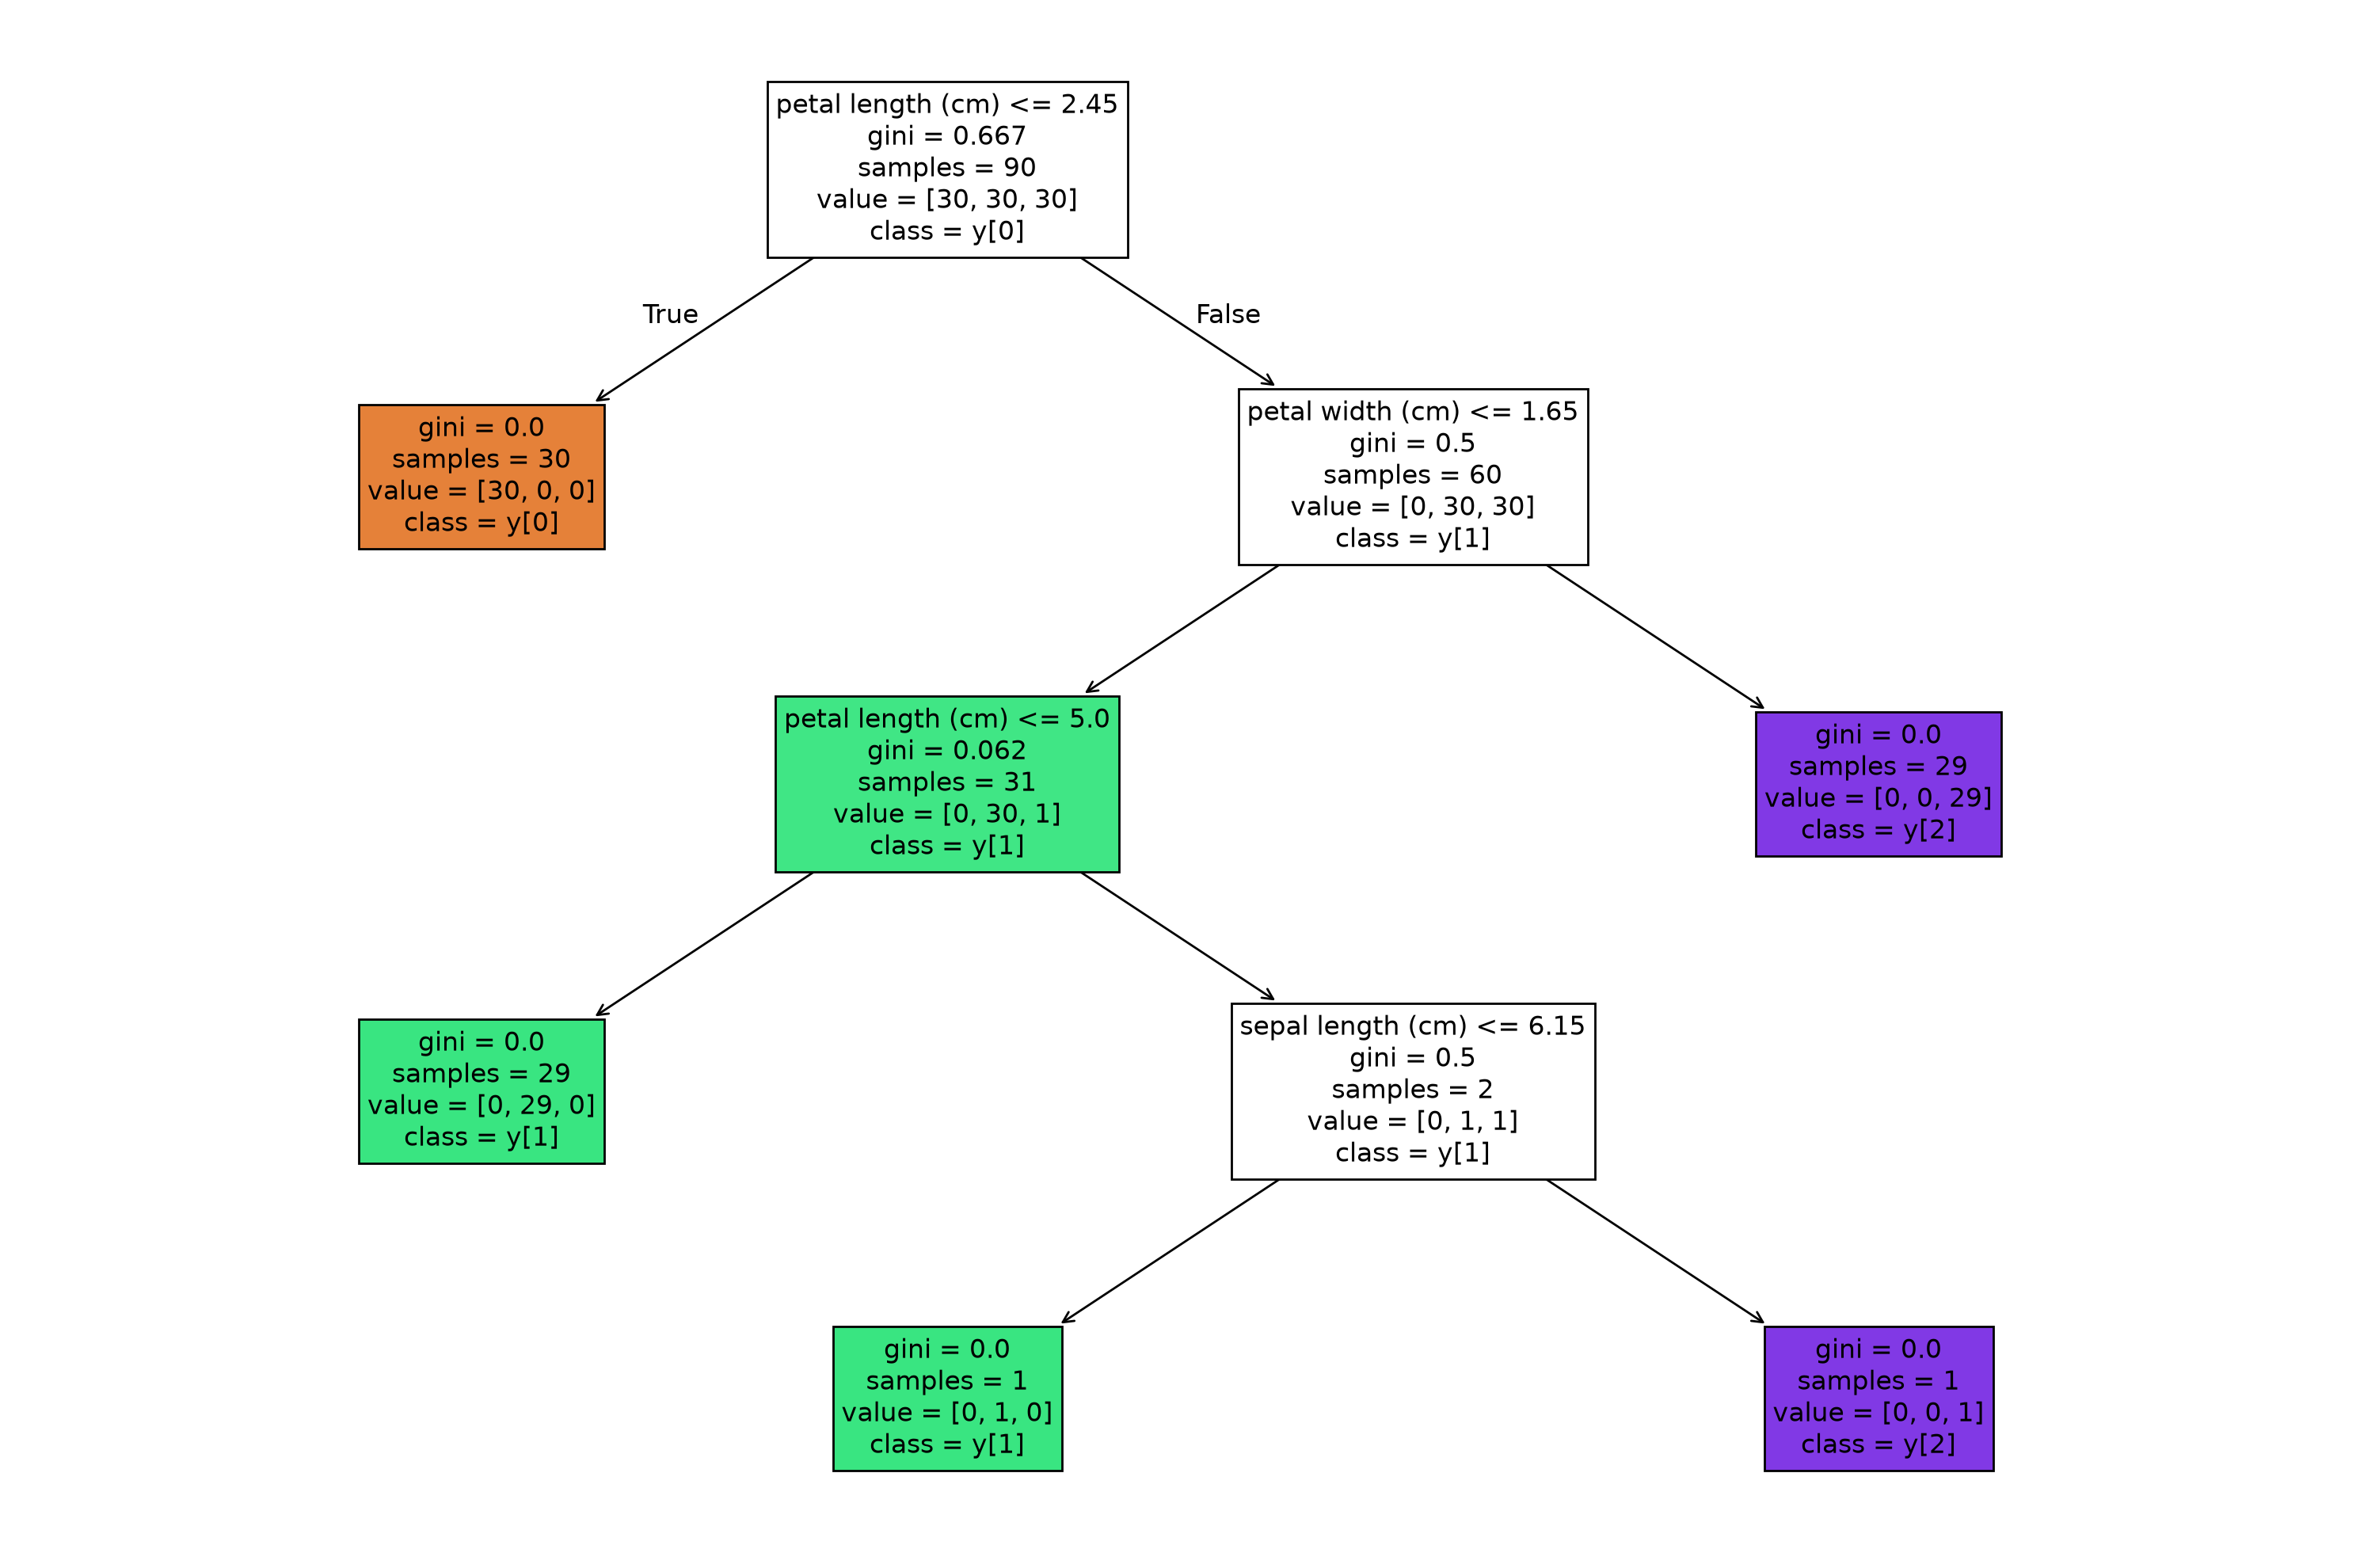

In [4]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(15, 10), dpi=200)

plot_tree(
    model,
    filled=True,
    max_depth=None,
    feature_names=X.columns,        # None -> x[0], x[1], ...
    class_names=True,               # or array-like.
    label='all',                    # {'all', 'root', 'none'} = 'all'.
    impurity=True,
    node_ids=False,
    proportion=False,               # if True, a `values` and `samples` become ratio.

    precision=3,                    # number of digits for float.
    rounded=False,                  # box and font style.
    fontsize=12,                    # font size.
    ax=ax,                          # plt axis to plot.
)

plt.tight_layout()
plt.show()

### `export_text`

In [5]:
from sklearn.tree import export_text

text = export_text(model)

pprint(text)

('|--- feature_2 <= 2.45\n'
 '|   |--- class: 0\n'
 '|--- feature_2 >  2.45\n'
 '|   |--- feature_3 <= 1.65\n'
 '|   |   |--- feature_2 <= 5.00\n'
 '|   |   |   |--- class: 1\n'
 '|   |   |--- feature_2 >  5.00\n'
 '|   |   |   |--- feature_0 <= 6.15\n'
 '|   |   |   |   |--- class: 1\n'
 '|   |   |   |--- feature_0 >  6.15\n'
 '|   |   |   |   |--- class: 2\n'
 '|   |--- feature_3 >  1.65\n'
 '|   |   |--- class: 2\n')


# 2. Random Forest

1. Bootstrapping (`bootstrap=True`)
    - Randomly choose $N$ samples with replacement (duplication O).
2. Split
    - For each split, choose `max_features` random features.
    - Calculate the impurity and choose the best split.
3. Pre-pruning
    - Grow until the stopping condition meets (same as decision tree).
4. Create many trees
    - Repeat 1 ~ 3 independently to create many trees.
5. Prediction
    - Classification: soft-voting, i.e. mean of probabilities.
    - Regression: mean.

```python
from sklearn.ensemble import RandomForestClassifier

class RandomForestClassifier(
    n_estimators: Int = 100,
    criterion: Literal['gini', 'entropy', 'log_loss'] = "gini",
    max_depth: Int | None = None,
    min_samples_split: float = 2,
    min_samples_leaf: float = 1,
    min_weight_fraction_leaf: Float = 0,
    max_features: float | Literal['sqrt', 'log2'] = "sqrt",     # e.g. 0.8 -> use 80% of all features per split.
    max_leaf_nodes: Int | None = None,
    min_impurity_decrease: Float = 0,
    bootstrap: bool = True,
    oob_score: bool = False,    # out-of-bag score.
    n_jobs: Int | None = None,
    random_state: Int | RandomState | None = None,
    verbose: Int = 0,
    warm_start: bool = False,
    class_weight: Mapping | Sequence[Mapping] | Literal['balanced', 'balanced_subsample'] | None = None,
    ccp_alpha: float = 0,
    max_samples: float | None = None
)
```

# 3. AdaBoost

## 1) Summary

### Algorithm - SAMME

- Build trees sequentially. Increase the **sample weights** of mistakes, so the next tree pays more attention to them.
- $K$: number of classes
- $T$: number of trees
- $\eta$: `learning_rate`
- $\mathbf{1}[A]$: 1 if $A$ is true, otherwise 0.

1. Start with the equal sample weights: $w_i=1/m$.
2. Fit a small classification tree $f_t$ using these weights (usually a stump of `max_depth=1`).
    - Use weighted class proportions when calculating Gini: $p_k=\frac{\sum_{i:y_i=k}w_i}{\sum_i w_i}$ within the node.
3. Calculate the tree's weighted error and voting weight:
    - $\epsilon_t=\sum_i w_i\mathbf{1}[f_t(x_i)\ne y_i]$
    - $\alpha_t=\eta\left[\ln\frac{1-\epsilon_t}{\epsilon_t}+\ln(K-1)\right]$
4. Increase incorrect samples' weights:
    - $w_i\leftarrow w_i\exp\left(\alpha_t\mathbf{1}[f_t(x_i)\ne y_i]\right)$
5. Normalize all weights to sum to 1:
    - $w_i\leftarrow\frac{w_i}{\sum_jw_j}$
6. Repeat until:
    - at `n_estimators` or a perfect fit.
    - a tree with $\epsilon_t\geq1-1/K$ is rejected and training stops; if it is the first tree, fitting fails.
7. Predict by **weighted hard voting**, not Random Forest's average of probabilities:
    - $\hat y(x)=\arg\max_k\sum_{t=1}^T\alpha_t\mathbf{1}[f_t(x)=k]$
    - For $\epsilon_t=0$, keep the perfect tree and stop without evaluating the logarithm. `predict_proba()` converts ensemble decision scores to probabilities.
> Note) For regression, `AdaBoostRegressor` uses **AdaBoost.R2**, a different error/weight update, and predicts a weighted median.<br>
> The SAMME formulas above are for classification.

### Example

- Let $K=2$, $\eta=1$, $x=[1,2,3,4]$, $y=[0,1,0,1]$, and all $w_i=1/4$.
- Suppose the stump splits at $x\leq1.5$ and predicts $[0,1,1,1]$. Only sample 3 is wrong.
    - $\epsilon_1=\frac14,\qquad \alpha_1=\ln\frac{3/4}{1/4}+\ln1=\ln3$
- Updated weights:
    - $[1/4,1/4,(1/4)\times3,1/4]$, with sum $3/2$
    - $w_{norm}=\left[\frac16,\frac16,\frac12,\frac16\right]$
- The next tree sees the same rows, but sample 3 now carries half of the total weight.

## 2) API

```python
class AdaBoostClassifier(
    estimator: Any = None,
    *,
    n_estimators: Int = 50,
    learning_rate: Float = 1,
    algorithm: Literal['SAMME', 'SAMME.R'] = "SAMME.R",
    random_state: Int | RandomState | None = None,
    base_estimator: Any = "deprecated"
)
```

In [6]:
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.tree import DecisionTreeClassifier

# Class
estimator = DecisionTreeClassifier(max_depth=1)
model = AdaBoostClassifier(
    estimator=estimator,    # decision stump; must support `sample_weight`.
    n_estimators=100,       # maximum number of trees.
    learning_rate=0.5,      # scales each tree's voting weight.
    random_state=seed,
)

# Methods
model.fit(X_train, y_train)
model.predict(X_test)
model.predict_proba(X_test)     # derived from ensemble decision scores.
model.score(X_test, y_test)

# Attributes
model.estimators_
model.estimator_weights_        # alpha_t.
model.estimator_errors_         # epsilon_t.
model.feature_importances_

array([0.09969122, 0.04237476, 0.35944019, 0.49849382])

# 4. GBDT

## 1) Summary

- Gradient boosting: each new tree outputs a **numerical correction** to the current prediction.
- Even for classification, these trees output scores, not class votes.

### Algorithm - Squared-Error Regression

- $F_M(x)=F_0(x)+\eta\displaystyle\sum_{t=1}^{M}h_t(x)$
    - $\eta$ = learning rate
    - $M$ = boosting iterations
- Generally, trees learn **negative loss gradients**, which equal residuals for $L=\frac12(y-F)^2$.


1. Initialize the prediction by mean: $F_0(x)=\bar y$.
2. Calculate residuals: $R_{t-1}(x_i)=y_i-F_{t-1}(x_i)$.
3. Fit a regression tree $h_t$ using **original features → residuals**. Each leaf predicts its mean residual.
4. Update: $F_t(x)=F_{t-1}(x)+\eta h_t(x)$.
5. Repeat.

### Example

| $x$ | $y$ | $F_0$ | $R_0=y-F_0$ | $h_1$ | $F_1=F_0+0.1h_1$ | $R_1=y-F_1$ | ... |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 1 | 10 | 16 | -6 | -5 | 15.5 | -5.5 | ... |
| 2 | 12 | 16 | -4 | -5 | 15.5 | -3.5 | ... |
| 3 | 20 | 16 | 4 | 5 | 16.5 | 3.5 | ... |
| 4 | 22 | 16 | 6 | 5 | 16.5 | 5.5 | ... |

- $F_0=(10+12+20+22)/4=16$, $\eta=0.1$.
- First tree splits at $x\leq2.5$:
  - Left leaf: $(-6-4)/2=-5$.
  - Right leaf: $(4+6)/2=5$.
- Next tree learns $R_1$, not the original $y$.

## 2) API

### `GradientBoostingClassifier`

```python
from sklearn.ensemble import GradientBoostingClassifier

class GradientBoostingClassifier(
    *,
    loss: Literal['log_loss', 'exponential'] = 'log_loss',
    learning_rate: Float = 0.1,          # η.
    n_estimators: Int = 100,             # maximum boosting iterations.
    subsample: Float = 1.0,              # training-sample fraction per iteration.
    min_samples_split: Int | Float = 2,
    min_samples_leaf: Int | Float = 1,
    min_weight_fraction_leaf: Float = 0.0,
    max_depth: Int | None = 3,           # depth of each tree.
    min_impurity_decrease: Float = 0.0,
    init: Any | Literal['zero'] | None = None,
    random_state: Int | RandomState | None = None,
    max_features: Int | Float | Literal['sqrt', 'log2'] | None = None,  # features per split; None = all.
    verbose: Int = 0,
    max_leaf_nodes: Int | None = None,
    warm_start: Bool = False,
    validation_fraction: Float = 0.1,
    n_iter_no_change: Int | None = None,  # early-stopping patience; None = disabled.
    tol: Float = 1e-4,
    ccp_alpha: Float = 0.0,
)
```

### `GradientBoostingRegressor`

```python
from sklearn.ensemble import GradientBoostingRegressor

class GradientBoostingRegressor(
    *,
    loss: Literal['squared_error', 'absolute_error', 'huber', 'quantile'] = 'squared_error',
    learning_rate: Float = 0.1,          # η.
    n_estimators: Int = 100,             # Number of boosting iterations.
    subsample: Float = 1.0,              # Fraction of samples used for each tree.
    min_samples_split: Int | Float = 2,
    min_samples_leaf: Int | Float = 1,
    min_weight_fraction_leaf: Float = 0.0,
    max_depth: Int | None = 3,
    min_impurity_decrease: Float = 0.0,
    init: Any | Literal['zero'] | None = None,
    random_state: Int | RandomState | None = None,
    max_features: Int | Float | Literal['sqrt', 'log2'] | None = None,
    alpha: Float = 0.9,                   # Quantile for {'huber', 'quantile'} loss.
    verbose: Int = 0,
    max_leaf_nodes: Int | None = None,
    warm_start: Bool = False,
    validation_fraction: Float = 0.1,
    n_iter_no_change: Int | None = None,  # Early-stopping patience.
    tol: Float = 1e-4,
    ccp_alpha: Float = 0.0,
)
```

### HistGradientBoostingClassifier

- Bin continuous features into fewer candidate split locations.
- Much faster for large dataset.

```python
from sklearn.ensemble import HistGradientBoostingClassifier

class HistGradientBoostingClassifier(
    *,
    loss: Literal['log_loss'] = 'log_loss',
    learning_rate: Float = 0.1,           # η.
    max_iter: Int = 100,                  # use `max_iter` instead of `n_estimators`.
    max_leaf_nodes: Int | None = 31,
    max_depth: Int | None = None,
    min_samples_leaf: Int = 20,
    l2_regularization: Float = 0.0,
    max_features: Float = 1.0,            # fraction of features considered per split.
    max_bins: Int = 255,                  # maximum bins per numerical feature.
    categorical_features: Any = 'from_dtype',
    monotonic_cst: Any = None,
    interaction_cst: Any = None,
    warm_start: Bool = False,
    early_stopping: Literal['auto'] | Bool = 'auto',
    scoring: Str | Callable | None = 'loss',
    validation_fraction: Int | Float | None = 0.1,
    n_iter_no_change: Int = 10,           # early-stopping patience.
    tol: Float = 1e-7,
    verbose: Int = 0,
    random_state: Int | RandomState | None = None,
    class_weight: Mapping | Literal['balanced'] | None = None,
)
```

### HistGradientBoostingRegressor

```python
from sklearn.ensemble import HistGradientBoostingRegressor

class HistGradientBoostingRegressor(
    *,
    loss: Literal['squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'] = 'squared_error',
    quantile: Float | None = None,         # quantile for `loss='quantile'`.
    learning_rate: Float = 0.1,            # η.
    max_iter: Int = 100,                   # use `max_iter` instead of `n_estimators`.
    max_leaf_nodes: Int | None = 31,
    max_depth: Int | None = None,
    min_samples_leaf: Int = 20,
    l2_regularization: Float = 0.0,
    max_features: Float = 1.0,             # fraction of features considered per split.
    max_bins: Int = 255,                   # maximum bins per numerical feature.
    categorical_features: Any = 'from_dtype',
    monotonic_cst: Any = None,
    interaction_cst: Any = None,
    warm_start: Bool = False,
    early_stopping: Literal['auto'] | Bool = 'auto',
    scoring: Str | Callable | None = 'loss',
    validation_fraction: Int | Float | None = 0.1,
    n_iter_no_change: Int = 10,            # early-stopping patience.
    tol: Float = 1e-7,
    verbose: Int = 0,
    random_state: Int | RandomState | None = None,
)
```

# 4. XGBoost

## 1) Summary

### Algorithm

- $F_i = F(x_i)$ = current raw score
- $L(y_i,F(x_i))$ = loss
- $\eta$ = learning rate

1. Initialize the prediction by mean: $F_0(x)=\bar y$.
2. Calculate the loss slope $g_i$ and curvature $h_i$ for each training sample:
    - $g_i=\frac{\partial L(y_i,F_i)}{\partial F_i}$
    - $h_i=\frac{\partial^2L(y_i,F_i)}{\partial F_i^2}$
3. Give each leaf its correction $v_\ell=-G_\ell/(H_\ell+\lambda)$.
4. Grow a tree using each correction, respecting a depth, child-weight, and gain limits.
5. Add the new tree: $F_t(x)=F_{t-1}(x)+\eta f_t(x)$.
6. Recalculate $g_i,h_i$ and repeat until `n_estimators` or early stopping.

### Gradients / Split gain

- Squared-error regression
  - $L(y_i, p_i) = \tfrac12(F_i-y_i)^2$
  - $g_i=\frac{\partial L}{\partial F_i}=F_i-y_i$
  - $h_i=\frac{\partial F_i^2}{\partial^2L}1$
- Binary log loss
  - $p_i=\sigma(F_i)=\frac{1}{1+e^{-F_i}}$
  - $L(y_i, p_i) = -y_i \log p_i - (1-y_i) \log (1-p_i)$
  - $g_i=p_i-y_i$
  - $h_i=p_i(1-p_i)$
- Gain (L2-regularization only, i.e. `reg_alpha=0`)
  - $Gain=\left[\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}-\frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right]-\gamma$
  - For any node, $G=\sum_i g_i$ and $H=\sum_i h_i$ over its samples.
  - $\lambda$: penalty on large leaf values
  - $\gamma$: penalty for adding a leaf. A positive gain improves this approximate regularized objective.

### Prediction

- $F_T(x)=F_0(x)+\eta\sum_{t=1}^T f_t(x)$
- Regression: output $F_T$.
- Binary classification: apply sigmoid, $p=1/(1+e^{-F_T})$.
- Multiclass: keep a score $F_k$ per class and apply softmax, $p_k=e^{F_k}/\sum_j e^{F_j}$; choose the largest probability.

### Example

- Binary classification.

1. Init
    - $x=[1,2,3,4]$
    - $y=[0,0,1,1]$
    - $\lambda=1$, $\gamma=0$, $\eta=0.3$.
    - Allow small leaves (`min_child_weight=0`).
    - $F_0=[0,0,0,0]$
2. Calculate $g$, $h$
    - $p=[0.5,0.5,0.5,0.5]$
    - $g=[0.5,0.5,-0.5,-0.5]$
    - $h=[0.25,0.25,0.25,0.25]$
3. At $x\leq2.5$
    - $G_L=1$
    - $H_L=0.5$
    - $G_R=-1$
    - $H_R=0.5$.
4. $Gain=\frac12\left(\frac{1^2}{1.5}+\frac{(-1)^2}{1.5}-\frac{0^2}{2}\right)=\frac23$
5. The other candidate thresholds, $1.5$ and $3.5$, each give gain $6/35 \approx 0.1714$. Choose $2.5$.
    - $v_L=-\frac{1}{1.5}=-\frac23$
    - $v_R=-\frac{-1}{1.5}=\frac23$
6. After this depth-1 tree:
    - $F_1=[-0.2,-0.2,0.2,0.2]$
    - $p_1\approx[0.4502,0.4502,0.5498,0.5498]$

## 2) API

### `XGBClassifier`

```python
from xgboost import XGBClassifier

class XGBClassifier(
    *,
    objective: Str | Callable = 'binary:logistic',
    n_estimators: Int | None = None,              # Number of boosting rounds; effective default = 100.
    learning_rate: Float | None = None,            # η.
    max_depth: Int | None = None,
    max_leaves: Int | None = None,
    max_bin: Int | None = None,                    # Number of histogram bins.
    grow_policy: Literal['depthwise', 'lossguide'] | None = None,

    gamma: Float | None = None,                    # γ; minimum loss reduction required for a split.
    min_child_weight: Float | None = None,         # Minimum sum of Hessians in a child.
    reg_alpha: Float | None = None,                # L1 regularization.
    reg_lambda: Float | None = None,               # L2 regularization.

    subsample: Float | None = None,                # Fraction of samples per tree.
    colsample_bytree: Float | None = None,         # Fraction of features per tree.
    colsample_bylevel: Float | None = None,        # Fraction of features per level.
    colsample_bynode: Float | None = None,         # Fraction of features per split.

    scale_pos_weight: Float | None = None,         # Weight for positive class.
    tree_method: Str | None = None,                # e.g. 'hist'.
    device: Str | None = None,                     # e.g. 'cpu', 'cuda'.
    eval_metric: Str | list | Callable | None = None,
    early_stopping_rounds: Int | None = None,

    random_state: Int | RandomState | Generator | None = None,
    n_jobs: Int | None = None,
    missing: Float = np.nan,
    enable_categorical: Bool = True,

    **kwargs: Any,
)
```

### `XGBRegressor`

```python
from xgboost import XGBRegressor

class XGBRegressor(
    *,
    objective: Str | Callable = 'reg:squarederror',
    n_estimators: Int | None = None,              # Number of boosting rounds; effective default = 100.
    learning_rate: Float | None = None,            # η.
    max_depth: Int | None = None,
    max_leaves: Int | None = None,
    max_bin: Int | None = None,                    # Number of histogram bins.
    grow_policy: Literal['depthwise', 'lossguide'] | None = None,

    gamma: Float | None = None,                    # γ; minimum loss reduction required for a split.
    min_child_weight: Float | None = None,         # Minimum sum of Hessians in a child.
    reg_alpha: Float | None = None,                # L1 regularization.
    reg_lambda: Float | None = None,               # L2 regularization.

    subsample: Float | None = None,                # Fraction of samples per tree.
    colsample_bytree: Float | None = None,         # Fraction of features per tree.
    colsample_bylevel: Float | None = None,        # Fraction of features per level.
    colsample_bynode: Float | None = None,         # Fraction of features per split.

    tree_method: Str | None = None,                # e.g. 'hist'.
    device: Str | None = None,                     # e.g. 'cpu', 'cuda'.
    eval_metric: Str | list | Callable | None = None,
    early_stopping_rounds: Int | None = None,

    random_state: Int | RandomState | Generator | None = None,
    n_jobs: Int | None = None,
    missing: Float = np.nan,
    enable_categorical: Bool = True,

    **kwargs: Any,
)

# 5. LightGBM

## 1) Summary

- **Histogram-based GBDT**
  - Numerical features → up to `max_bin` bins.
- $F_i=F(x_i)$ = raw score.
- $\eta$ = learning rate.

### Algorithm

1. Initialize (unweighted)
    - Squared error → $F_0=\bar y$.
    - Binary log loss → $F_0=\log\frac{\bar y}{1-\bar y}$, where $0<\bar y<1$.
2. Calculate $g_i,h_i$
    - Sum per feature bin.
3. **Leaf-wise growth**
    - Split the leaf with the largest gain across the tree.
    - Repeat until `num_leaves`, `max_depth`, or other split limits.
4. Leaf values / update
    - $v_\ell=-G_\ell/(H_\ell+\lambda)$.
    - $F_t(x)=F_{t-1}(x)+\eta f_t(x)$.
5. Repeat
    - Recalculate $g_i,h_i$.
    - Stop at `n_estimators` or early stopping.

### Gradients / Split gain

- Squared-error regression
  - $g_i=F_i-y_i$.
  - $h_i=1$.
- Binary log loss
  - $p_i=\sigma(F_i)$.
  - $g_i=p_i-y_i$.
  - $h_i=p_i(1-p_i)$.
- Numerical split gain (L2 only, `reg_alpha=0`)
  - $G=\sum_i g_i$, $H=\sum_i h_i$ within each node.
  - $Gain=\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}-\frac{(G_L+G_R)^2}{H_L+H_R+\lambda}$.
  - $\lambda$ = `reg_lambda`.
  - Split requires $Gain>$ `min_split_gain` and valid child leaves.

### Features

- **Histogram subtraction**
  - Parent histogram $-$ one child’s histogram = other child’s histogram.
- **GOSS** (Gradient-based One-Side Sampling)
  - Keep large-gradient samples.
  - Sample smaller-gradient samples.
  - Upweight the sampled group.
  - Optional → `data_sample_strategy='goss'`.
- **EFB** (Exclusive Feature Bundling)
  - Bundle sparse features with rarely overlapping nonzero values.
  - Default → `enable_bundle=True`.
- **Categorical splits**
  - Categories → two groups using gradient/Hessian statistics.
  - Category codes ≠ numerical magnitudes.
  - Few categories → one-vs-rest splits possible.
- **Overfitting control**
  - Large `num_leaves` → overfitting risk on small datasets.
  - `max_depth` limits depth, not leaf-wise growth order.

### Prediction

- Standard GBDT
  - $F_T(x)=F_0(x)+\eta\sum_{t=1}^T f_t(x)$.
- Squared-error regression
  - Output $F_T$.
- Binary classification
  - $p=\sigma(F_T)=1/(1+e^{-F_T})$.
- Multiclass
  - $p_k=e^{F_k}/\sum_j e^{F_j}$.
  - Predict the class with the largest probability.

### Example

- Squared-error regression
  - One tree with 3 leaves.

1. Init
    - $F_0=17$, $\lambda=0$, $\eta=0.1$.
    - `num_leaves=3`, `min_split_gain=0`.
    - `min_child_samples=1`, `min_data_in_bin=1`.
    - $g=[7,5,-3,-9]$, $h=[1,1,1,1]$.
2. Root split at $x\leq2.5$
    - $G_L=12$, $H_L=2$, $G_R=-12$, $H_R=2$.
    - $Gain=12^2/2+(-12)^2/2-0^2/4=144$.
3. Next leaf to split
    - Left, $x\leq1.5$ → $Gain=7^2+5^2-12^2/2=2$.
    - Right, $x\leq3.5$ → $Gain=(-3)^2+(-9)^2-(-12)^2/2=18$.
    - $18>2$ → split **only the right leaf**.
    - Stop at 3 leaves.

| $x$ | $y$ | $F_0$ | $f_1(x)=v_\ell$ | $F_1=F_0+0.1f_1$ |
|---:|---:|---:|---:|---:|
| 1 | 10 | 17 | -6 | 16.4 |
| 2 | 12 | 17 | -6 | 16.4 |
| 3 | 20 | 17 | 3 | 17.3 |
| 4 | 26 | 17 | 9 | 17.9 |

- Gradient recalculation
  - After adding the complete tree, not after each split.

## 2) API

### `LGBMClassifier`

```python
from lightgbm import LGBMClassifier

class LGBMClassifier(
    *,
    boosting_type: Literal['gbdt', 'dart', 'rf'] = 'gbdt',
    num_leaves: Int = 31,                         # Maximum leaves per tree.
    max_depth: Int = -1,                          # <= 0 = no depth limit.
    learning_rate: Float = 0.1,                   # η.
    n_estimators: Int = 100,                      # Boosting iterations.
    subsample_for_bin: Int = 200000,
    objective: Str | Callable | None = None,      # Auto: 'binary' or 'multiclass'.
    class_weight: Mapping | Literal['balanced'] | None = None,

    min_split_gain: Float = 0.0,
    min_child_weight: Float = 1e-3,                # Minimum child Hessian sum.
    min_child_samples: Int = 20,                  # Minimum samples per leaf.
    reg_alpha: Float = 0.0,                       # L1 regularization.
    reg_lambda: Float = 0.0,                      # L2 regularization.

    subsample: Float = 1.0,                       # Row fraction; requires subsample_freq > 0.
    subsample_freq: Int = 0,                      # 0 = disable row bagging.
    colsample_bytree: Float = 1.0,                 # Feature fraction per tree.
    random_state: Int | RandomState | Generator | None = None,
    n_jobs: Int | None = None,
    importance_type: Literal['split', 'gain'] = 'split',

    # Core **kwargs options; effective defaults.
    max_bin: Int = 255,
    min_data_in_bin: Int = 3,
    data_sample_strategy: Literal['bagging', 'goss'] = 'bagging',
    top_rate: Float = 0.2,                        # GOSS: large-gradient group.
    other_rate: Float = 0.1,                      # GOSS: sampled smaller-gradient group.
    enable_bundle: Bool = True,                   # EFB.
    device_type: Literal['cpu', 'gpu', 'cuda'] = 'cpu',
    **kwargs: Any,
)
```

### `LGBMRegressor`

```python
from lightgbm import LGBMRegressor

class LGBMRegressor(
    *,
    boosting_type: Literal['gbdt', 'dart', 'rf'] = 'gbdt',
    num_leaves: Int = 31,
    max_depth: Int = -1,                          # <= 0 = no depth limit.
    learning_rate: Float = 0.1,                   # η.
    n_estimators: Int = 100,
    subsample_for_bin: Int = 200000,
    objective: Str | Callable | None = None,      # Default = 'regression' (squared error).
    class_weight: Mapping | Literal['balanced'] | None = None,  # Classification only.

    min_split_gain: Float = 0.0,
    min_child_weight: Float = 1e-3,
    min_child_samples: Int = 20,
    reg_alpha: Float = 0.0,
    reg_lambda: Float = 0.0,

    subsample: Float = 1.0,
    subsample_freq: Int = 0,                      # > 0 enables subsample < 1.
    colsample_bytree: Float = 1.0,
    random_state: Int | RandomState | Generator | None = None,
    n_jobs: Int | None = None,
    importance_type: Literal['split', 'gain'] = 'split',

    # Core **kwargs options; effective defaults.
    max_bin: Int = 255,
    min_data_in_bin: Int = 3,
    data_sample_strategy: Literal['bagging', 'goss'] = 'bagging',
    top_rate: Float = 0.2,
    other_rate: Float = 0.1,
    enable_bundle: Bool = True,
    device_type: Literal['cpu', 'gpu', 'cuda'] = 'cpu',
    **kwargs: Any,
)
```

- Categorical columns
  - `categorical_feature` → `fit()` parameter.
  - `'auto'` → unordered pandas categorical columns.
- Early stopping
  - Validation `eval_set` + `lightgbm.early_stopping(...)` callback.
  - Callback → `fit(callbacks=...)`.
  - No effect with `boosting_type='dart'`.

# 6. CatBoost

## 1) Summary

- **CatBoost**
  - GBDT + native categorical-feature processing.
- **Symmetric (oblivious) trees** — default
  - Same split condition at every node of the same depth.
  - Depth $d$ → $2^d$ leaf slots.

### Algorithm

1. Initialize
    - Constant raw score $F_0$.
2. Prepare features
    - Numerical → bins.
    - Categorical → ordered statistics or one-hot encoding.
3. Calculate gradients
    - `Ordered` → predictions from preceding-row models.
4. Grow tree
    - One shared split per depth.
5. Leaf values / update
    - Estimate corrections with `l2_leaf_reg`.
    - $F_t(x)=F_{t-1}(x)+\eta f_t(x)$.
6. Repeat
    - Stop at `iterations` or early stopping.

### Ordered Target Statistics

- Training
  - Randomly permute rows.
  - Encode using earlier targets from the same category.
  - Exclude the current row’s target.
- Binary-target statistic (one example)
  - $z_i=\frac{\sum_{j<i}\mathbf{1}[c_j=c_i]y_j+p_0}{\sum_{j<i}\mathbf{1}[c_j=c_i]+1}$.
  - $c_i$ = category, $p_0$ = fixed prior.
  - No earlier match → $z_i=p_0$.
- Prediction
  - Use training targets, never validation/test targets.
  - $z_i$ = input feature, **not** the predicted class probability.

### Ordered Boosting

- Prefix model
  - $F_{t-1}^{<i}$ = model trained only on rows before $i$ in a permutation.
  - $g_i^{(t)}=\left.\frac{\partial L(y_i,F)}{\partial F}\right|_{F=F_{t-1}^{<i}(x_i)}$.
- Purpose
  - Reduce **prediction shift** from reusing training targets.
- Encoding ≠ boosting
  - `Plain` boosting can still use ordered categorical statistics.
  - `Ordered` boosting is optional, not a universal default.

### Gradients / Leaf Values

- Binary log loss
  - $p_i=\sigma(F_i)$.
  - $g_i=p_i-y_i$, $h_i=p_i(1-p_i)$.
- One Newton step (unweighted, initial leaf value $0$)
  - $v_\ell=-\frac{\sum_{i\in\ell}g_i}{\sum_{i\in\ell}h_i+\lambda}$.
  - $\lambda$ = L2 leaf penalty.
- Actual leaf estimation
  - Method / number of steps depend on the loss.
  - `leaf_estimation_method`, `leaf_estimation_iterations`.
- Split scoring
  - Controlled by `score_function`, not the leaf-value formula.

### Prediction

- Standard GBDT
  - $F_T(x)=F_0(x)+\eta\sum_{t=1}^T f_t(x)$.
- RMSE regression
  - Output $F_T$.
- Binary classification
  - $p=\sigma(F_T)=1/(1+e^{-F_T})$.
- Multiclass
  - $p_k=e^{F_k}/\sum_j e^{F_j}$.
  - Predict the class with the largest probability.

### Example

- Ordered binary-target statistic
  - Permutation order shown below.
  - $p_0=0.5$, `one_hot_max_size=1`.

| Position $i$ | Category $c_i$ | $y_i$ | Earlier $y$ (same category) | $z_i$ |
|---:|:---:|---:|:---|---:|
| 1 | A | 1 | None | $0.5/1=0.5$ |
| 2 | B | 0 | None | $0.5/1=0.5$ |
| 3 | A | 0 | $[1]$ | $(1+0.5)/2=0.75$ |
| 4 | A | 1 | $[1,0]$ | $(1+0.5)/3=0.5$ |
| 5 | B | 1 | $[0]$ | $(0+0.5)/2=0.25$ |

- New rows — use all training targets
  - A → $(1+0+1+0.5)/(3+1)=0.625$.
  - B → $(0+1+0.5)/(2+1)=0.5$.
  - Unseen C → $0.5$.

## 2) API

- Selected constructor parameters
  - `None` → internal default.
  - Effective defaults depend on the loss and CPU/GPU.

### `CatBoostClassifier`

```python
from catboost import CatBoostClassifier

class CatBoostClassifier(
    iterations: Int | None = None,               # Default = 1000; alias: n_estimators.
    learning_rate: Float | None = None,           # η; auto or 0.03.
    depth: Int | None = None,                     # SymmetricTree default = 6.
    loss_function: Str | object | None = None,    # Auto: 'Logloss' or 'MultiClass'.
    l2_leaf_reg: Float | None = None,             # L2 penalty; default = 3.
    grow_policy: Literal['SymmetricTree', 'Depthwise', 'Lossguide'] | None = None,
    boosting_type: Literal['Ordered', 'Plain'] | None = None,

    cat_features: Sequence[Int | Str] | None = None,  # Categorical indices / names.
    one_hot_max_size: Int | None = None,          # One-hot threshold.
    border_count: Int | None = None,              # Numerical bin thresholds.
    leaf_estimation_method: Literal['Newton', 'Gradient', 'Exact'] | None = None,
    leaf_estimation_iterations: Int | None = None,

    random_strength: Float | None = None,         # Randomness in split scores.
    bootstrap_type: Str | None = None,            # e.g. 'Bayesian', 'Bernoulli', 'MVS', 'No'.
    bagging_temperature: Float | None = None,     # Bayesian bootstrap only.
    subsample: Float | None = None,               # Bernoulli / MVS / Poisson bootstrap.
    rsm: Float | None = None,                     # Feature-sampling fraction.
    class_weights: Sequence | Mapping | None = None,
    auto_class_weights: Literal['Balanced', 'SqrtBalanced', 'None'] | None = None,

    eval_metric: Str | object | None = None,
    early_stopping_rounds: Int | None = None,      # Patience; requires eval_set.
    use_best_model: Bool | None = None,           # Best iteration; requires eval_set.
    task_type: Literal['CPU', 'GPU'] | None = None,  # Default = 'CPU'.
    thread_count: Int | None = None,
    random_seed: Int | None = None,               # Default = 0.
    verbose: Bool | Int | None = None,
    # Other parameters omitted.
)
```

### `CatBoostRegressor`

```python
from catboost import CatBoostRegressor

class CatBoostRegressor(
    iterations: Int | None = None,               # Default = 1000.
    learning_rate: Float | None = None,           # η; auto or 0.03.
    depth: Int | None = None,                     # SymmetricTree default = 6.
    loss_function: Str | object = 'RMSE',         # e.g. 'RMSE', 'MAE', 'Quantile'.
    l2_leaf_reg: Float | None = None,              # Default = 3.
    grow_policy: Literal['SymmetricTree', 'Depthwise', 'Lossguide'] | None = None,
    boosting_type: Literal['Ordered', 'Plain'] | None = None,

    cat_features: Sequence[Int | Str] | None = None,
    one_hot_max_size: Int | None = None,
    border_count: Int | None = None,
    leaf_estimation_method: Literal['Newton', 'Gradient', 'Exact'] | None = None,
    leaf_estimation_iterations: Int | None = None,

    random_strength: Float | None = None,
    bootstrap_type: Str | None = None,
    bagging_temperature: Float | None = None,     # Bayesian bootstrap only.
    subsample: Float | None = None,
    rsm: Float | None = None,

    eval_metric: Str | object | None = None,
    early_stopping_rounds: Int | None = None,
    use_best_model: Bool | None = None,
    task_type: Literal['CPU', 'GPU'] | None = None,
    thread_count: Int | None = None,
    random_seed: Int | None = None,
    verbose: Bool | Int | None = None,
    # Other parameters omitted.
)
```

- Categorical columns
  - `cat_features` → column names / indices.
  - No manual one-hot encoding.
- Validation
  - `early_stopping_rounds` → stopping patience.
  - `use_best_model` → retain trees up to the best validation iteration.
  - Both use validation `eval_set`.
- Class weights
  - Do not combine `class_weights` with `auto_class_weights` or `scale_pos_weight`.